### A demo of line art colorization
- Input: a reference image and a line art image
    - resize to 512*512
- Output: colorized image of the line art
    - original model output is 512*512

In [1]:
import os
import pandas as pd
import torch
import yaml
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T
import numpy as np
from datetime import datetime
from safetensors.torch import load_file
from diffusers.pipelines import FluxPipeline
from torchvision import transforms

from src.flux.condition import Condition
from src.flux.generate import generate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/opt/conda/envs/mangaDiT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_latest_checkpoint(runs_dir):
    """Load the latest checkpoint"""
    # Get the latest run directory
    run_dirs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
    if not run_dirs:
        raise ValueError("No run directories found")
    latest_run = sorted(run_dirs)[-1]
    
    # Get the checkpoint directory
    ckpt_dir = os.path.join(runs_dir, latest_run, "ckpt")
    if not os.path.exists(ckpt_dir):
        raise ValueError(f"No checkpoint directory found in {latest_run}")
    
    # Get the latest checkpoint file
    ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith('.safetensors')]
    if not ckpt_files:
        raise ValueError(f"No checkpoint files found in {ckpt_dir}")
    latest_ckpt = sorted(ckpt_files)[-1]
    
    return os.path.join(ckpt_dir, latest_ckpt)

def load_config(config_path):
    """Load configuration file"""
    with open(config_path, 'r') as f:
        return yaml.safe_load(f)

def init_pipeline(config, checkpoint_path):
    """Initialize model pipeline"""
    # Initialize FluxPipeline
    pipe = FluxPipeline.from_pretrained(
        config["flux_path"], 
        torch_dtype=getattr(torch, config["dtype"])
    )
    pipe = pipe.to("cuda")
    
    # Load LoRA weights
    pipe.load_lora_weights(
        checkpoint_path,
        adapter_name="lineart_ref"
    )
    
    return pipe

def prepare_images(lineart_path, ref_path, condition_size=512):
    """Prepare input images"""
    # Load and resize images
    lineart_img = Image.open(lineart_path).resize((condition_size, condition_size)).convert("RGB")
    
    ref_img = Image.open(ref_path).resize((condition_size, condition_size)).convert("RGBA")
    bg = Image.new("RGBA", ref_img.size, (0, 0, 0, 255)) # change ref image to black bg
    # bg = Image.new("RGBA", ref_img.size, (255, 255, 255, 255)) # change ref image to white bg
    composited = Image.alpha_composite(bg, ref_img)
    ref_img = composited.convert("RGB")
    
    return lineart_img, ref_img

In [3]:
def extract_lineart(img):
    # load model from lllyasviel/Annotators sk_model
    from src.annotator.lineart import BatchLineartDetector
    annotator_ckpts_path = "annotators"
    preprocessor = BatchLineartDetector(annotator_ckpts_path)
    preprocessor.to(device,dtype=torch.float32)
    # Convert to tensor and add batch dimension
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert to [C, H, W] with value range [0, 1]
    ])
    input_tensor = transform(img).unsqueeze(0)  # Become [1, 3, H, W]
    input_tensor = input_tensor.to('cuda')
    
    # Process image and extract lineart
    lineart_img = preprocessor(input_tensor).squeeze().cpu().numpy()
    lineart_img = (lineart_img * 255).clip(0, 255).astype(np.uint8)  # Convert to uint8 image format
    lineart_img_convert = Image.fromarray(255 - np.array(lineart_img))
    
    # Directly convert to RGB format without saving temporary files
    lineart_img_convert = lineart_img_convert.convert("RGB")
    return lineart_img_convert

In [4]:
def process_images(ref_img, lineart_img, seed=42):
    runs_dir = "runs/20250709-084341"
    config_path = "ops/config/lineart_512.yaml"
    
    # Load configuration and model
    config = load_config(config_path)
    checkpoint_path = os.path.join(runs_dir, "ckpt", "50000", "pytorch_lora_weights.safetensors")
    condition_size=config["train"]["dataset"]["condition_size"]
    
    # Initialize model
    pipe = init_pipeline(config, checkpoint_path)
        
    # Create conditions
    condition_1 = Condition(
        condition_type="lineart",
        condition=lineart_img.resize(
            (condition_size, condition_size)
        ).convert("RGB"),
        position_delta=[0, 0]
    )
    condition_2 = Condition(
        condition_type="reference",
        condition=ref_img.resize(
            (condition_size, condition_size)
        ).convert("RGB"),
        position_delta=[0, 0]
    )
    
    # Generate image
    with torch.no_grad():
        result = generate(
            pipe,
            prompt="",
            conditions=[condition_1, condition_2],
            height=config["train"]["dataset"]["target_size"],
            width=config["train"]["dataset"]["target_size"],
            generator=torch.Generator(device="cuda").manual_seed(42),
            model_config=config.get("model", {}),
            default_lora=True
        )
        
    # Get the generated image
    generated_image = result.images[0]
    
    return generated_image

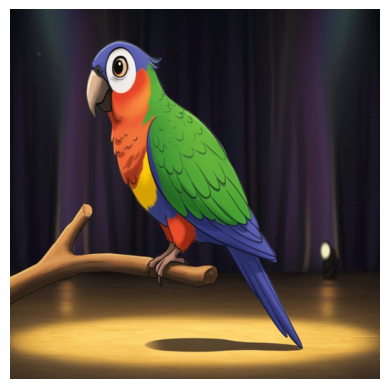

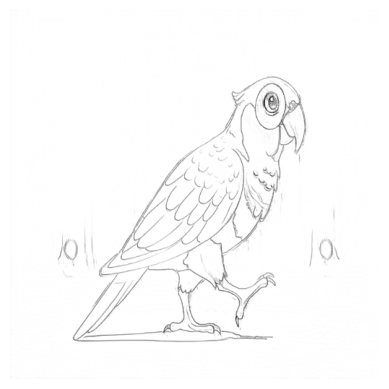

In [ ]:
# read line art image and reference image from samples file
import matplotlib.pyplot as plt

ref_path = "samples/bg_7_1.png"
lineart_path = "samples/bg_7_2_line.png"
lineart_img, ref_img = prepare_images(lineart_path, ref_path)

plt.imshow(ref_img)
plt.axis('off')
plt.show()

# Optional: extract line art for better result
lineart_img = extract_lineart(lineart_img)

plt.imshow(lineart_img)
plt.axis('off')
plt.show()


100%|██████████| 28/28 [00:19<00:00,  1.46it/s]


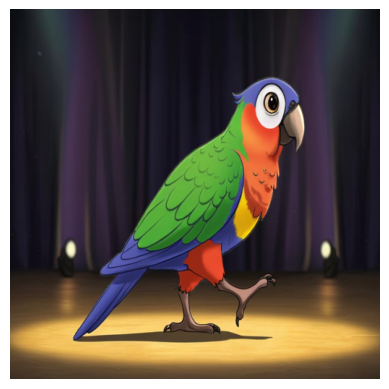

In [6]:
result = process_images(ref_img, lineart_img)
plt.imshow(result)
plt.axis('off')
plt.show()